## 1. 导入依赖

In [2]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.set_printoptions(precision=4, sci_mode=False)

print("PyTorch版本：", torch.__version__)
print("是否可以使用GPU：", torch.cuda.is_available())

PyTorch版本： 2.8.0+cpu
是否可以使用GPU： False


## 2. 基础缩放点积注意力

核心公式：

`Attention(Q, K, V) = softmax(QKᵀ / √dₖ)V`

下面返回三个结果，便于观察中间过程：

- `scores`：缩放后的相似度分数
- `weights`：Softmax 后的注意力权重
- `output`：对 Value 加权求和后的输出

In [3]:
def self_attention(query, key, value):
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / (d_k ** 0.5)
    weights = F.softmax(scores, dim=-1)   #Softmax计算注意力权重
    output = torch.matmul(weights, value)
    return output, weights, scores

print("基础自注意力函数定义完成")

基础自注意力函数定义完成


### 准备 Q、K、V

In [4]:
query = torch.tensor([[[1.0, 0.0, 1.0, 0.0], [0.0, 1.0, 0.0, 1.0], [1.0, 1.0, 0.0, 0.0]]])
key = query.clone()
value = torch.tensor([[[1.0, 0.0, 0.0, 1.0], [0.0, 2.0, 0.0, 0.0], [1.0, 1.0, 1.0, 0.0]]])

print("Query形状：", query.shape)
print("Key形状：", key.shape)
print("Value形状：", value.shape)
print("\nQuery：\n", query)
print("\nValue：\n", value)

Query形状： torch.Size([1, 3, 4])
Key形状： torch.Size([1, 3, 4])
Value形状： torch.Size([1, 3, 4])

Query：
 tensor([[[1., 0., 1., 0.],
         [0., 1., 0., 1.],
         [1., 1., 0., 0.]]])

Value：
 tensor([[[1., 0., 0., 1.],
         [0., 2., 0., 0.],
         [1., 1., 1., 0.]]])


### 计算注意力

In [5]:
output, weights, scores = self_attention(query, key, value)

print("缩放后的相似度分数：\n", scores)
print("\n注意力权重：\n", weights)
print("\n注意力输出：\n", output)

缩放后的相似度分数：
 tensor([[[1.0000, 0.0000, 0.5000],
         [0.0000, 1.0000, 0.5000],
         [0.5000, 0.5000, 1.0000]]])

注意力权重：
 tensor([[[0.5065, 0.1863, 0.3072],
         [0.1863, 0.5065, 0.3072],
         [0.2741, 0.2741, 0.4519]]])

注意力输出：
 tensor([[[0.8137, 0.6798, 0.3072, 0.5065],
         [0.4935, 1.3202, 0.3072, 0.1863],
         [0.7259, 1.0000, 0.4519, 0.2741]]])


### 验证每行权重之和

In [6]:
print("每一行注意力权重之和：\n", weights.sum(dim=-1))

每一行注意力权重之和：
 tensor([[1., 1., 1.]])


### 查看第一个词对其他词的注意力

In [7]:
tokens = ["机器", "学习", "有趣"]
first_token_weights = weights[0, 0]

for token, weight in zip(tokens, first_token_weights): print(f"“{tokens[0]}”对“{token}”的注意力：{weight.item():.4f}")

“机器”对“机器”的注意力：0.5065
“机器”对“学习”的注意力：0.1863
“机器”对“有趣”的注意力：0.3072


### 可视化基础注意力矩阵

C:\Users\Administrator\.conda\envs\rl\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\.conda\envs\rl\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22120 (\N{CJK UNIFIED IDEOGRAPH-5668}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\.conda\envs\rl\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\.conda\envs\rl\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20064 (\N{CJK UNIFIED IDEOGRAPH-4E60}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\.conda\envs\rl\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26377

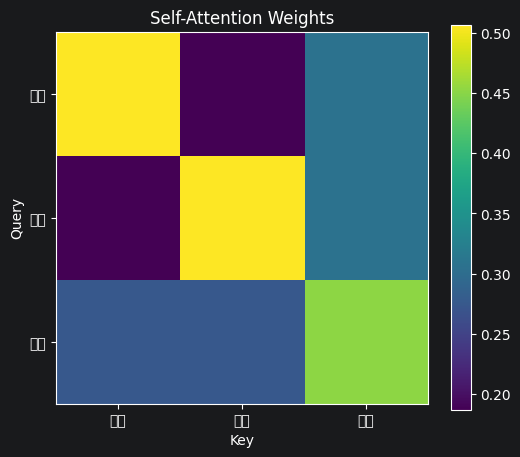

In [8]:
attention_matrix = weights[0].detach().cpu().numpy()

plt.figure(figsize=(6, 5))
plt.imshow(attention_matrix)
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Key")
plt.ylabel("Query")
plt.title("Self-Attention Weights")
plt.colorbar()
plt.show()

## 3. 多头注意力

原页面示例在拆分多头后没有正确交换维度。下面将张量转换为：

`[batch_size, num_heads, seq_len, d_k]`

再分别计算每个头的注意力。

In [9]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        if d_model % num_heads != 0: raise ValueError("d_model必须能够被num_heads整除")
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        batch_size, seq_len, _ = x.shape
        return x.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

    def forward(self, query, key, value):
        Q = self.split_heads(self.W_q(query))
        K = self.split_heads(self.W_k(key))
        V = self.split_heads(self.W_v(value))
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        weights = F.softmax(scores, dim=-1)
        head_outputs = torch.matmul(weights, V)
        batch_size = query.size(0)
        combined_output = head_outputs.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.W_o(combined_output)
        return output, weights, Q, K, V

print("多头注意力类定义完成")

多头注意力类定义完成


### 创建测试输入

In [10]:
batch_size, seq_len, d_model, num_heads = 1, 4, 8, 2
x = torch.randn(batch_size, seq_len, d_model)
multi_head_attention = MultiHeadAttention(d_model=d_model, num_heads=num_heads)

print("输入形状：", x.shape)
print("注意力头数量：", num_heads)
print("每个头的维度：", multi_head_attention.d_k)

输入形状： torch.Size([1, 4, 8])
注意力头数量： 2
每个头的维度： 4


### 运行多头注意力

In [11]:
multi_output, multi_weights, Q, K, V = multi_head_attention(x, x, x)

print("Q形状：", Q.shape)
print("K形状：", K.shape)
print("V形状：", V.shape)
print("注意力权重形状：", multi_weights.shape)
print("最终输出形状：", multi_output.shape)

Q形状： torch.Size([1, 2, 4, 4])
K形状： torch.Size([1, 2, 4, 4])
V形状： torch.Size([1, 2, 4, 4])
注意力权重形状： torch.Size([1, 2, 4, 4])
最终输出形状： torch.Size([1, 4, 8])


### 查看每个注意力头

In [12]:
for head_index in range(num_heads):
    print(f"第{head_index + 1}个注意力头：")
    print(multi_weights[0, head_index])
    print("每行权重之和：", multi_weights[0, head_index].sum(dim=-1))
    print("-" * 60)

第1个注意力头：
tensor([[0.1209, 0.1200, 0.3972, 0.3619],
        [0.1491, 0.2459, 0.2552, 0.3498],
        [0.3363, 0.3990, 0.1731, 0.0916],
        [0.2164, 0.3025, 0.3072, 0.1740]], grad_fn=<SelectBackward0>)
每行权重之和： tensor([1., 1., 1., 1.], grad_fn=<SumBackward1>)
------------------------------------------------------------
第2个注意力头：
tensor([[0.3356, 0.2490, 0.2271, 0.1883],
        [0.1728, 0.2638, 0.2619, 0.3015],
        [0.1802, 0.1997, 0.1528, 0.4672],
        [0.1116, 0.2798, 0.2904, 0.3182]], grad_fn=<SelectBackward0>)
每行权重之和： tensor([1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)
------------------------------------------------------------


### 分别绘制每个注意力头

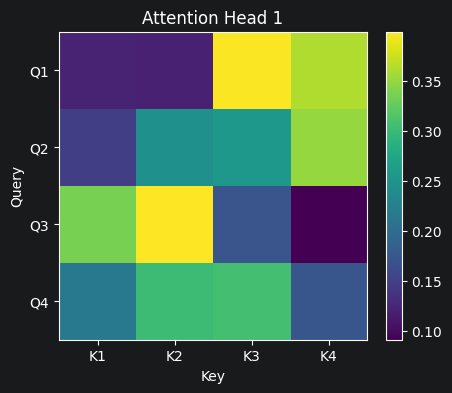

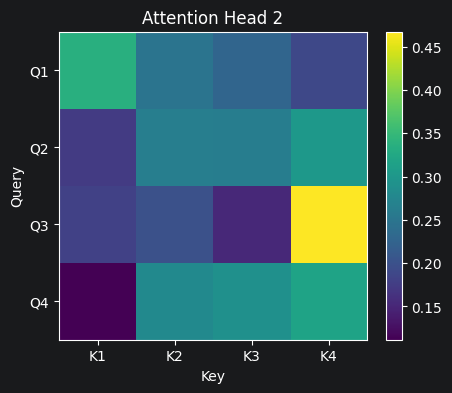

In [13]:
for head_index in range(num_heads):
    matrix = multi_weights[0, head_index].detach().cpu().numpy()
    plt.figure(figsize=(5, 4))
    plt.imshow(matrix)
    plt.xticks(range(seq_len), [f"K{i + 1}" for i in range(seq_len)])
    plt.yticks(range(seq_len), [f"Q{i + 1}" for i in range(seq_len)])
    plt.xlabel("Key")
    plt.ylabel("Query")
    plt.title(f"Attention Head {head_index + 1}")
    plt.colorbar()
    plt.show()

## 4. 简单注意力层

这个注意力层为编码器的每一个位置计算一个分数，再对全部编码器输出进行加权求和。

In [14]:
class SimpleAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, encoder_outputs):
        attention_scores = self.attention(encoder_outputs).squeeze(-1)
        attention_weights = F.softmax(attention_scores, dim=1)
        context_vector = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context_vector, attention_weights, attention_scores

print("SimpleAttention定义完成")

SimpleAttention定义完成


### 准备编码器输出

In [15]:
encoder_outputs = torch.randn(1, 4, 6)
simple_attention = SimpleAttention(hidden_size=6)

print("编码器输出形状：", encoder_outputs.shape)
print("\n编码器输出：\n", encoder_outputs)

编码器输出形状： torch.Size([1, 4, 6])

编码器输出：
 tensor([[[ 0.4334, -0.7172,  1.0554, -1.4534,  0.4652,  0.3714],
         [-0.0047,  0.0795,  0.3273,  0.1292,  2.8520, -0.7436],
         [ 0.1954, -1.3350,  0.3945,  1.7060, -0.3071, -0.7155],
         [ 0.0762, -0.2127, -0.5663,  0.3989,  1.3695, -0.2519]]])


### 运行简单注意力

In [16]:
context_vector, simple_weights, simple_scores = simple_attention(encoder_outputs)

print("注意力原始分数：\n", simple_scores)
print("\n注意力权重：\n", simple_weights)
print("\n上下文向量：\n", context_vector)
print("\n上下文向量形状：", context_vector.shape)

注意力原始分数：
 tensor([[-0.1160,  0.3936,  0.1269,  0.5592]], grad_fn=<SqueezeBackward1>)

注意力权重：
 tensor([[0.1694, 0.2819, 0.2159, 0.3327]], grad_fn=<SoftmaxBackward0>)

上下文向量：
 tensor([[ 0.1396, -0.4581,  0.1678,  0.2914,  1.2722, -0.3851]],
       grad_fn=<SqueezeBackward1>)

上下文向量形状： torch.Size([1, 6])


### 逐个查看词语权重

In [17]:
sentence_tokens = ["人工智能", "正在", "改变", "世界"]

for token, weight in zip(sentence_tokens, simple_weights[0]): print(f"{token}：{weight.item():.4f}")
print("权重总和：", simple_weights[0].sum().item())

人工智能：0.1694
正在：0.2819
改变：0.2159
世界：0.3327
权重总和： 1.0


## 5. 注意力权重可视化

In [18]:
def plot_attention(attention_weights, source_tokens, target_tokens):
    matrix = attention_weights.detach().cpu().numpy() if isinstance(attention_weights, torch.Tensor) else attention_weights
    plt.figure(figsize=(10, 7))
    plt.imshow(matrix, aspect="auto")
    plt.xticks(range(len(source_tokens)), source_tokens, rotation=45)
    plt.yticks(range(len(target_tokens)), target_tokens)
    plt.xlabel("Source Tokens")
    plt.ylabel("Target Tokens")
    plt.title("Attention Weights Visualization")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

print("注意力可视化函数定义完成")

注意力可视化函数定义完成


### 生成模拟翻译注意力

In [19]:
source_tokens = ["The", "cat", "sat", "on", "the", "mat"]
target_tokens = ["Le", "chat", "s'est", "assis", "sur", "le", "tapis"]
translation_attention = F.softmax(torch.randn(len(target_tokens), len(source_tokens)), dim=-1)

print("注意力矩阵形状：", translation_attention.shape)
print("每一行权重之和：", translation_attention.sum(dim=-1))

注意力矩阵形状： torch.Size([7, 6])
每一行权重之和： tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


### 绘制模拟翻译注意力

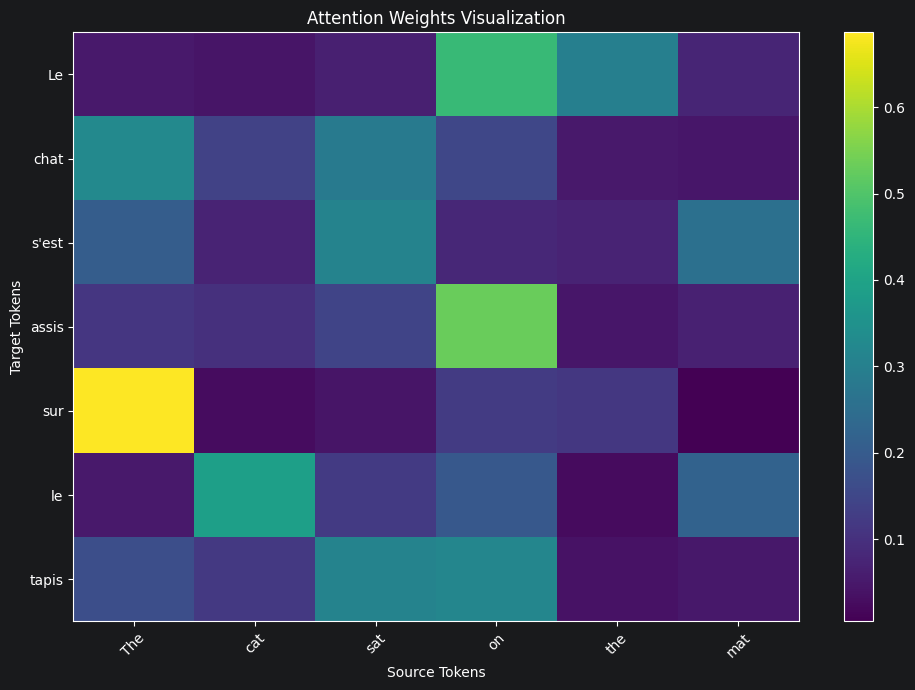

In [20]:
plot_attention(translation_attention, source_tokens, target_tokens)

## 6. 使用本地 BERT 获取真实注意力权重

这部分使用本地英文 BERT：

`D:\11\NLP\data\bert-base-uncased-local`

文件夹中至少应有：

- `config.json`
- `model.safetensors` 或 `pytorch_model.bin`
- `tokenizer_config.json`
- `vocab.txt`

模型下载地址：Hugging Face 的 `google-bert/bert-base-uncased` 文件页面。手动下载时，权重只选 `model.safetensors` 或 `pytorch_model.bin` 中的一种。代码设置了 `local_files_only=True`，运行时不会联网。

### 检查本地 BERT 文件

In [21]:
bert_path = r"D:\11\NLP\data\hf_cache_bert_uncased"
required_files = ["config.json", "tokenizer_config.json", "vocab.txt"]
weight_files = ["model.safetensors", "pytorch_model.bin"]

print("模型文件夹是否存在：", os.path.isdir(bert_path))
for file_name in required_files: print(f"{file_name}：", "存在" if os.path.isfile(os.path.join(bert_path, file_name)) else "缺失")
print("模型权重：", "存在" if any(os.path.isfile(os.path.join(bert_path, name)) for name in weight_files) else "缺失")

模型文件夹是否存在： True
config.json： 存在
tokenizer_config.json： 存在
vocab.txt： 存在
模型权重： 存在


### 从本地加载 BERT

In [22]:
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained(bert_path, local_files_only=True)
bert_model = BertModel.from_pretrained(bert_path, local_files_only=True, output_attentions=True)
bert_model.eval()

print("BERT加载成功")
print("隐藏层数量：", bert_model.config.num_hidden_layers)
print("注意力头数量：", bert_model.config.num_attention_heads)
print("隐藏层维度：", bert_model.config.hidden_size)

C:\Users\Administrator\.conda\envs\rl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BERT加载成功
隐藏层数量： 12
注意力头数量： 12
隐藏层维度： 768


### 对英文句子分词

In [23]:
text = "The cat is sitting on the mat."
inputs = tokenizer(text, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

print("原始句子：", text)
print("Token编号：", inputs["input_ids"])
print("分词结果：", tokens)

原始句子： The cat is sitting on the mat.
Token编号： tensor([[  101,  1996,  4937,  2003,  3564,  2006,  1996, 13523,  1012,   102]])
分词结果： ['[CLS]', 'the', 'cat', 'is', 'sitting', 'on', 'the', 'mat', '.', '[SEP]']


### 运行 BERT 并获取全部注意力层

In [24]:
with torch.no_grad(): bert_outputs = bert_model(**inputs, output_attentions=True)

bert_attentions = bert_outputs.attentions

print("注意力层数量：", len(bert_attentions))
print("第一层注意力形状：", bert_attentions[0].shape)
print("最后一层注意力形状：", bert_attentions[-1].shape)

注意力层数量： 12
第一层注意力形状： torch.Size([1, 12, 10, 10])
最后一层注意力形状： torch.Size([1, 12, 10, 10])


### 查看最后一层第一个注意力头

In [25]:
layer_index, head_index = len(bert_attentions) - 1, 0
bert_attention_matrix = bert_attentions[layer_index][0, head_index]

print("选择的层：", layer_index + 1)
print("选择的注意力头：", head_index + 1)
print("注意力矩阵形状：", bert_attention_matrix.shape)
print("\n注意力矩阵：\n", bert_attention_matrix)

选择的层： 12
选择的注意力头： 1
注意力矩阵形状： torch.Size([10, 10])

注意力矩阵：
 tensor([[    0.2454,     0.0251,     0.0636,     0.0688,     0.0132,     0.0042,
             0.0058,     0.0136,     0.2748,     0.2855],
        [    0.0126,     0.0090,     0.0126,     0.0134,     0.0029,     0.0013,
             0.0021,     0.0021,     0.5118,     0.4322],
        [    0.0078,     0.0043,     0.0061,     0.0038,     0.0008,     0.0005,
             0.0010,     0.0007,     0.5480,     0.4269],
        [    0.0212,     0.0065,     0.0057,     0.0145,     0.0024,     0.0014,
             0.0024,     0.0027,     0.5116,     0.4317],
        [    0.0087,     0.0028,     0.0049,     0.0038,     0.0006,     0.0004,
             0.0008,     0.0007,     0.5367,     0.4408],
        [    0.0159,     0.0019,     0.0051,     0.0017,     0.0007,     0.0004,
             0.0009,     0.0008,     0.5366,     0.4359],
        [    0.0114,     0.0076,     0.0127,     0.0064,     0.0038,     0.0016,
             0.0028,     0

### 查看 cat 对其他 Token 的注意力

In [26]:
query_token = "cat"
query_index = tokens.index(query_token)
query_weights = bert_attention_matrix[query_index]

for token, weight in zip(tokens, query_weights): print(f"cat → {token}：{weight.item():.4f}")
print("权重总和：", query_weights.sum().item())

cat → [CLS]：0.0078
cat → the：0.0043
cat → cat：0.0061
cat → is：0.0038
cat → sitting：0.0008
cat → on：0.0005
cat → the：0.0010
cat → mat：0.0007
cat → .：0.5480
cat → [SEP]：0.4269
权重总和： 0.9999998807907104


### 可视化 BERT 的一个注意力头

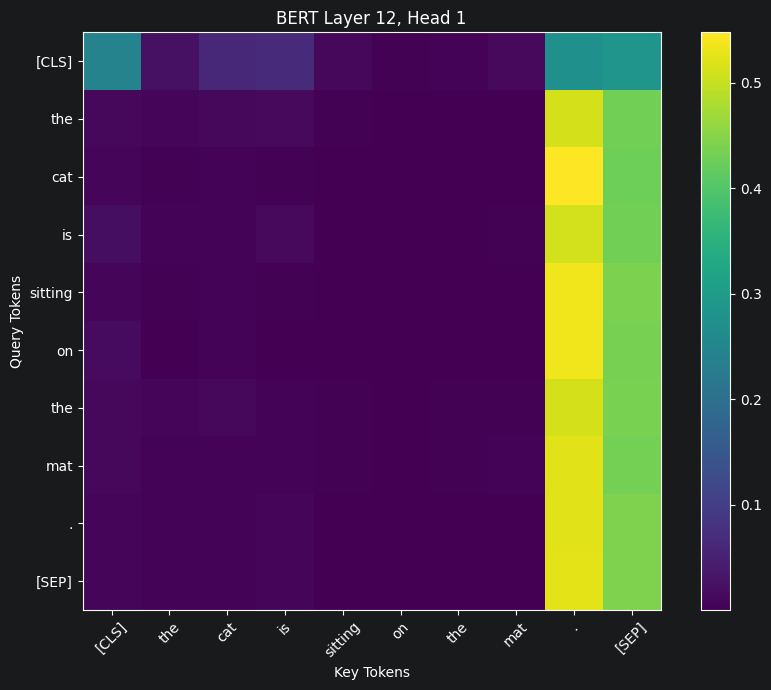

In [27]:
matrix = bert_attention_matrix.detach().cpu().numpy()

plt.figure(figsize=(9, 7))
plt.imshow(matrix)
plt.xticks(range(len(tokens)), tokens, rotation=45)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title(f"BERT Layer {layer_index + 1}, Head {head_index + 1}")
plt.colorbar()
plt.tight_layout()
plt.show()

### 计算最后一层所有注意力头的平均值

In [28]:
average_attention = bert_attentions[-1][0].mean(dim=0)

print("平均注意力矩阵形状：", average_attention.shape)
print("每一行权重之和：", average_attention.sum(dim=-1))

平均注意力矩阵形状： torch.Size([10, 10])
每一行权重之和： tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000])


### 可视化最后一层平均注意力

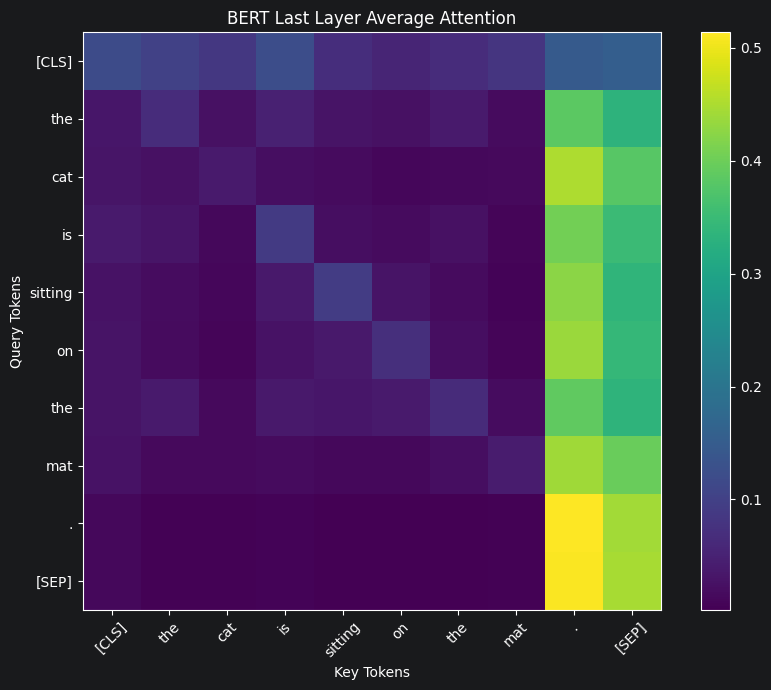

In [29]:
average_matrix = average_attention.detach().cpu().numpy()

plt.figure(figsize=(9, 7))
plt.imshow(average_matrix)
plt.xticks(range(len(tokens)), tokens, rotation=45)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("BERT Last Layer Average Attention")
plt.colorbar()
plt.tight_layout()
plt.show()